# Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import pingouin as pg
from mlxtend.frequent_patterns import apriori, association_rules

# Clients' table

In [4]:
path_bhv = "..Data/QVI_purchase_behaviour.csv"
path_bhv = "/Users/ekaterinasorokopudova/Desktop/Quantium/Data/QVI_purchase_behaviour.csv"

In [5]:
df_bhv = pd.read_csv(path_bhv)

TimeoutError: [Errno 60] Operation timed out

In [ ]:
df_bhv

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [ ]:
print("\nSummary Table Generated by .info() Method:")
print(df_bhv.info())


Summary Table Generated by .info() Method:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [ ]:
all_duplicates = df_bhv[df_bhv.duplicated(keep=False)]
all_duplicates

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER


## EDA Clients

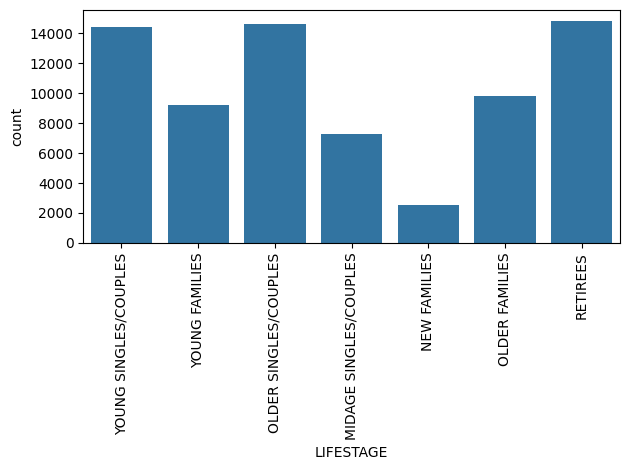

In [ ]:
ax = sns.countplot(data= df_bhv, x='LIFESTAGE')
ax.tick_params(axis='x', rotation= 90)
plt.tight_layout()

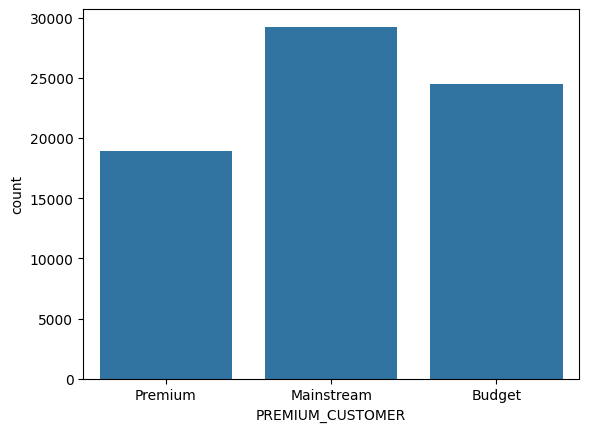

In [ ]:
ax = sns.countplot(data=df_bhv, 
                   x="PREMIUM_CUSTOMER")


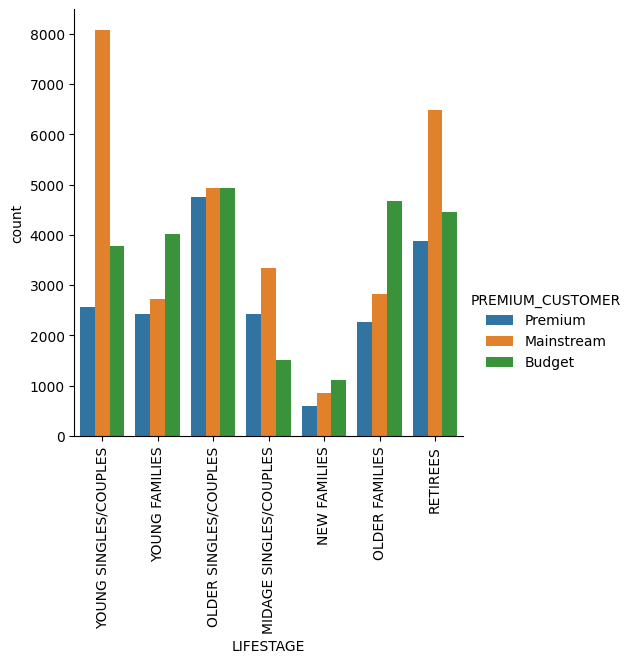

In [ ]:
ax = sns.catplot(data= df_bhv, x="LIFESTAGE", 
                 hue="PREMIUM_CUSTOMER", 
                 kind="count")
ax.tick_params(axis="x", rotation = 90)

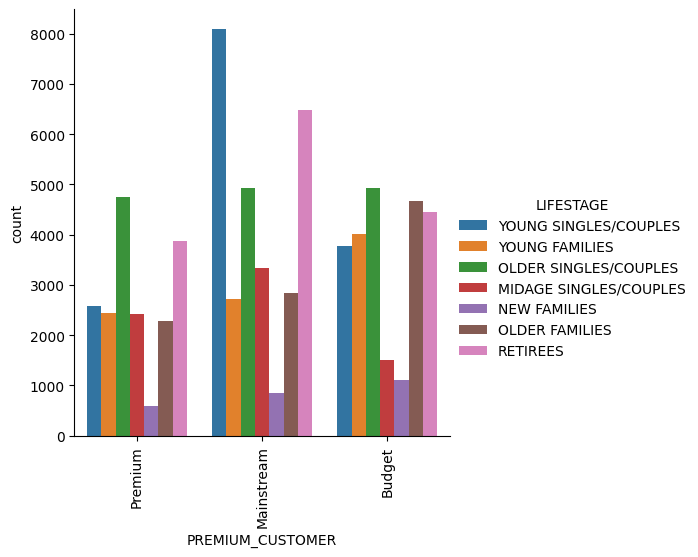

In [ ]:
ax = sns.catplot(data= df_bhv, x="PREMIUM_CUSTOMER", 
                 hue="LIFESTAGE", 
                 kind="count")
ax.tick_params(axis="x", rotation = 90)

# Transactions

In [ ]:
path = '../Data/QVI_transaction_data.xlsx'

In [ ]:
df = pd.read_excel(path)

In [ ]:
df.shape

(264836, 8)

In [ ]:
df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
print("\nSummary Table Generated by .info() Method:")
print(df.info())


Summary Table Generated by .info() Method:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
None


## Data cleaning 

### Date

In [ ]:
df["DATE"] = pd.to_datetime(df["DATE"], unit="D", origin="1899-12-30")

In [ ]:
df["DATE"].describe()

count                           264836
mean     2018-12-30 00:52:12.879215616
min                2018-07-01 00:00:00
25%                2018-09-30 00:00:00
50%                2018-12-30 00:00:00
75%                2019-03-31 00:00:00
max                2019-06-30 00:00:00
Name: DATE, dtype: object

In [ ]:
df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### Duplicates

In [ ]:
all_duplicates = df[df.duplicated(keep=False)]
all_duplicates

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [ ]:
df = df.drop_duplicates()

In [ ]:
all_duplicates = df[df.duplicated(keep=False)]
all_duplicates

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


### Product's name

#### Delete all no chips

In [ ]:
unique_products = (
    df["PROD_NAME"]
    .str.lower()
    .str.strip()
    .unique()
)

words = pd.Series(" ".join(unique_products).split())

clean_words = words[words.str.match("^[a-zA-Z]+$")]

word_counts = clean_words.value_counts()

print(word_counts.to_string())

chips              21
smiths             16
crinkle            14
cut                14
kettle             13
salt               12
cheese             12
original           10
doritos             9
chip                9
salsa               9
corn                8
pringles            8
rrd                 8
chicken             7
ww                  7
sea                 6
sour                6
thinly              5
crisps              5
vinegar             5
thins               5
chilli              5
supreme             4
deli                4
rock                4
red                 4
cream               4
natural             4
infuzions           4
mild                3
old                 3
dip                 3
tostitos            3
tomato              3
ccs                 3
paso                3
el                  3
tortilla            3
soy                 3
cobs                3
popd                3
twisties            3
lime                3
woolworths          3
sensations

In [ ]:
df[df["PROD_NAME"].str.contains("salsa", case=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
25,2019-05-15,39,39144,35506,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
32,2019-05-20,45,45127,41122,64,Red Rock Deli SR Salsa & Mzzrlla 150g,2,5.4
44,2018-08-18,56,56013,50090,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
63,2019-05-15,82,82480,82047,101,Doritos Salsa Medium 300g,1,2.6
...,...,...,...,...,...,...,...,...
264675,2019-04-20,265,265103,263419,59,Old El Paso Salsa Dip Tomato Med 300g,1,5.1
264678,2019-03-30,265,265111,263428,35,Woolworths Mild Salsa 300g,1,1.5
264719,2018-10-28,266,266278,264104,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
264734,2019-01-11,267,267324,264374,41,Doritos Salsa Mild 300g,1,2.6


In [ ]:
df = df[~df["PROD_NAME"].str.contains("salsa", case=False, na=False)]

In [ ]:
df.shape

(246741, 8)

In [ ]:
df[df["PROD_NAME"].str.contains("salsa", case=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


#### Weight separate  

In [ ]:
df["PACK_SIZE"] = df["PROD_NAME"].str.extract(r"(\d+)").astype(int)
df.head(3)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170


In [ ]:
null_count = df["PACK_SIZE"].isna().sum()
null_count

np.int64(0)

In [ ]:
df["PACK_SIZE"].describe().round()

count    246741.0
mean        176.0
std          59.0
min          70.0
25%         150.0
50%         170.0
75%         175.0
max         380.0
Name: PACK_SIZE, dtype: float64

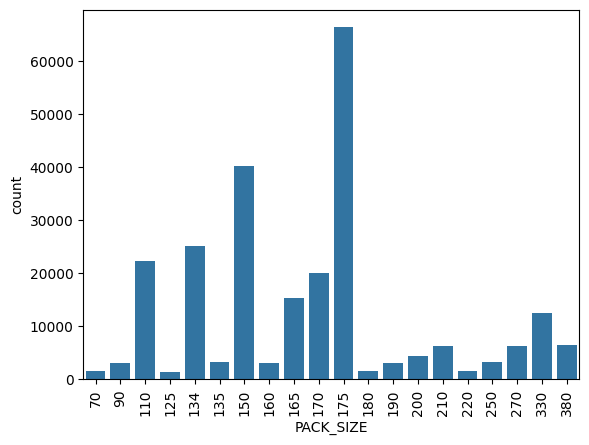

In [ ]:
ax = sns.countplot(data=df, x="PACK_SIZE")
ax.tick_params(axis="x", rotation = 90)

#### Brands name processing

In [ ]:
brand_count = df["PROD_NAME"].value_counts()

print(df["PROD_NAME"].nunique())
print("\n")
print(brand_count.to_string())

105


PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Dorito Corn Chp     Supreme 380g            3185
Pringles Sweet&Spcy BBQ 134g                3177
Infuzions BBQ Rib   Prawn Crackers 110g     3174
Tyrr

In [ ]:
brand_map = {
    "kettle": "Kettle",
    
    "cobs": "Cobs Popd",
    "cobs popd": "Cobs Popd",
    
    "tyrrells": "Tyrrells",

    "tostitos": "Tostitos",
    
    "infuzions": "Infuzions",
    "infzns": "Infuzions",
    
    "smiths": "Smiths",
    "smith": "Smiths",
    
    "thins": "Thins",
    
    "doritos": "Doritos",
    "dorito": "Doritos",
    
    "pringles": "Pringles",

    "twisties": "Twisties",
    
    "grain": "Grain Waves",
    "grain waves": "Grain Waves",
    "grnwves": "Grain Waves",
    
    "cheezels": "Cheezels",

    "natural chip": "Natural Chip Co",
    "natural chip co": "Natural Chip Co",
    "natural chipco": "Natural Chip Co",
    "ncc": "Natural Chip Co",
    
    "red": "Red Rock Deli",
    "rrd": "Red Rock Deli",
    "red rock deli": "Red Rock Deli",
    
    "woolworths": "Woolworths",
    "ww": "Woolworths",
    
    "cheetos": "Cheetos",
    
    "ccs": "CCs",
    
    "sunbites": "Sunbites",
    "sunbites whlegrn": "Sunbites",
    "snbts whlgrn": "Sunbites",

    "burger rings":"Burger rings",
    "burger":"Burger rings", 

    "french fries": "French fries",
    "french": "French fries"
}

In [ ]:
df["PROD_NAME"] = df["PROD_NAME"].str.lower().str.strip()

def extract_brand(product_name):
    for key, value in brand_map.items():
        if key in product_name:
            return value
    return "Unknown"

df["BRAND"] = df["PROD_NAME"].apply(extract_brand)

df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,Natural Chip Co
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,Kettle
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,175,Kettle
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,175,Tostitos
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,170,Doritos
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,150,Doritos


In [ ]:
brand_count = df["BRAND"].value_counts()
brand_count

BRAND
Kettle             41288
Smiths             30352
Doritos            25226
Pringles           25102
Red Rock Deli      16321
Infuzions          14201
Thins              14075
Woolworths         11836
Cobs Popd           9693
Tostitos            9471
Twisties            9454
Grain Waves         7740
Natural Chip Co     7469
Tyrrells            6442
Cheezels            4603
CCs                 4551
Sunbites            3008
Cheetos             2927
Burger rings        1564
French fries        1418
Name: count, dtype: int64

In [ ]:
df[df["BRAND"] == "Unknown"]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND


### Outliers

In [ ]:
print("\nSummary Table Generated by .describe() Method:")
print(df.describe().round())


Summary Table Generated by .describe() Method:
                                DATE  STORE_NBR  LYLTY_CARD_NBR     TXN_ID  \
count                         246741   246741.0        246741.0   246741.0   
mean   2018-12-30 01:19:32.745510656      135.0        135531.0   135131.0   
min              2018-07-01 00:00:00        1.0          1000.0        1.0   
25%              2018-09-30 00:00:00       70.0         70015.0    67569.0   
50%              2018-12-30 00:00:00      130.0        130367.0   135184.0   
75%              2019-03-31 00:00:00      203.0        203084.0   202654.0   
max              2019-06-30 00:00:00      272.0       2373711.0  2415841.0   
std                              NaN       77.0         80715.0    78148.0   

       PROD_NBR  PROD_QTY  TOT_SALES  PACK_SIZE  
count  246741.0  246741.0   246741.0   246741.0  
mean       56.0       2.0        7.0      176.0  
min         1.0       1.0        2.0       70.0  
25%        26.0       2.0        6.0      150.0  

In [ ]:
outlier_prod_qty = df[df['PROD_QTY'] == 200]
outlier_prod_qty

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0,380,Doritos
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0,380,Doritos


In [ ]:
transactions_by_user = df[df["LYLTY_CARD_NBR"] == 226000]
transactions_by_user

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0,380,Doritos
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0,380,Doritos


In [ ]:
df = df[~(df['LYLTY_CARD_NBR'] == 226000)]

In [ ]:
transactions_by_user = df[df["LYLTY_CARD_NBR"] == 226000]
transactions_by_user

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND


In [ ]:
df[['PROD_QTY',"TOT_SALES"]].describe().round()

,PROD_QTY,TOT_SALES
count,246739.0,246739.0
mean,2.0,7.0
std,0.0,2.0
min,1.0,2.0
25%,2.0,6.0
50%,2.0,7.0
75%,2.0,9.0
max,5.0,30.0


### Temporal data validation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246739 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246739 non-null  datetime64[ns]
 1   STORE_NBR       246739 non-null  int64         
 2   LYLTY_CARD_NBR  246739 non-null  int64         
 3   TXN_ID          246739 non-null  int64         
 4   PROD_NBR        246739 non-null  int64         
 5   PROD_NAME       246739 non-null  object        
 6   PROD_QTY        246739 non-null  int64         
 7   TOT_SALES       246739 non-null  float64       
 8   PACK_SIZE       246739 non-null  int64         
 9   BRAND           246739 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 20.7+ MB


In [ ]:
date_counts = df.groupby("DATE").size()

In [ ]:
df = df.set_index('DATE')

In [ ]:
all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

In [ ]:
missing_dates = all_days.difference(df.index)
missing_dates

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

In [ ]:
df = df.reset_index('DATE')

# Tabels merge

In [ ]:
df = df.merge(df_bhv,how= "inner", on="LYLTY_CARD_NBR")

df


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246734,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium
246735,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium
246736,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium
246737,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium


In [ ]:
df.to_csv("QVI_merged_tables.csv", index=False, encoding='utf-8')

In [ ]:
path = "../Data/QVI_merged_tables.csv"

df = pd.read_csv(path)
df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246739 entries, 0 to 246738
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              246739 non-null  object 
 1   STORE_NBR         246739 non-null  int64  
 2   LYLTY_CARD_NBR    246739 non-null  int64  
 3   TXN_ID            246739 non-null  int64  
 4   PROD_NBR          246739 non-null  int64  
 5   PROD_NAME         246739 non-null  object 
 6   PROD_QTY          246739 non-null  int64  
 7   TOT_SALES         246739 non-null  float64
 8   PACK_SIZE         246739 non-null  int64  
 9   BRAND             246739 non-null  object 
 10  LIFESTAGE         246739 non-null  object 
 11  PREMIUM_CUSTOMER  246739 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 22.6+ MB



# Calculating total sales by LIFESTAGE and PREMIUM_CUSTOMER


In [ ]:
total_sales_per_lifestage = df.groupby("LIFESTAGE").agg(
    customers = ("LYLTY_CARD_NBR", "nunique"),
    total_sales = ("TOT_SALES", "sum")
)
total_sales_per_lifestage = total_sales_per_lifestage.sort_values(
    by="total_sales", 
    ascending= False
    )
total_sales_per_lifestage

,customers,total_sales
LIFESTAGE,,
OLDER SINGLES/COUPLES,14389,376013.65
RETIREES,14555,342381.90
OLDER FAMILIES,9630,328519.90
YOUNG FAMILIES,9036,294627.90
YOUNG SINGLES/COUPLES,14044,243756.60
MIDAGE SINGLES/COUPLES,7141,172523.80
NEW FAMILIES,2492,47347.95


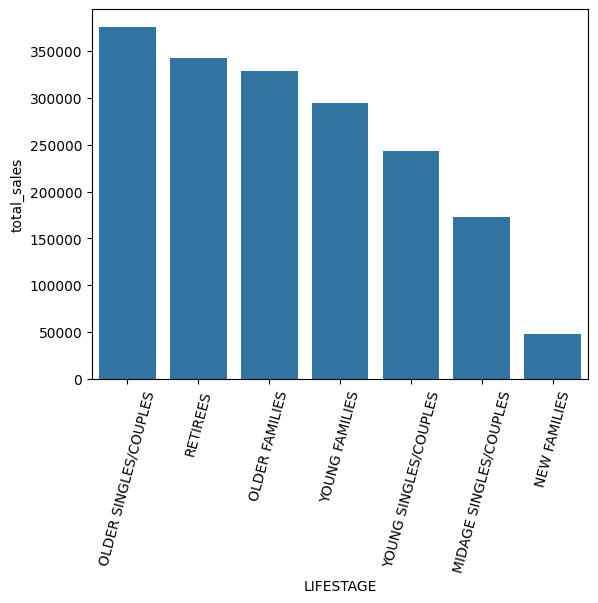

In [ ]:
ax = sns.barplot(data=total_sales_per_lifestage, x="LIFESTAGE", y="total_sales" )
ax.tick_params(axis='x', rotation= 75)

In [ ]:
total_sales_per_premium = df.groupby("PREMIUM_CUSTOMER").agg(
    customer = ("LYLTY_CARD_NBR", "nunique"), 
    total_sales = ("TOT_SALES","sum")
)

total_sales_per_premium = total_sales_per_premium.sort_values(
    by= "total_sales",
    ascending= False
)
total_sales_per_premium

,customer,total_sales
PREMIUM_CUSTOMER,,
Mainstream,28734,700865.40
Budget,24006,631406.85
Premium,18547,472899.45


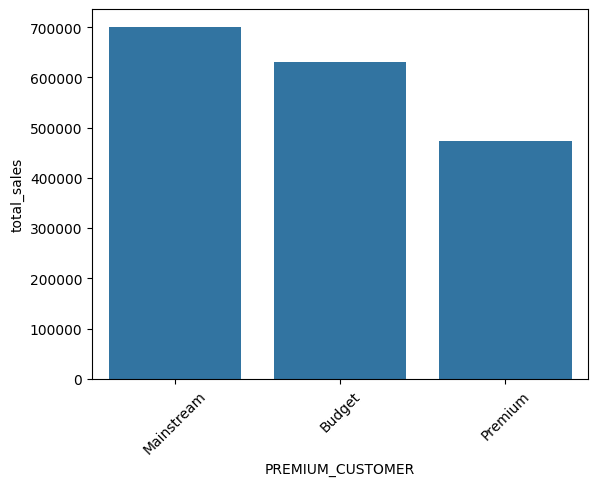

In [ ]:
ax = sns.barplot(data = total_sales_per_premium, x = "PREMIUM_CUSTOMER", y = "total_sales")
ax.tick_params(axis = "x", rotation = 45)

In [ ]:
cross_table = df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"]).agg(
    customer = ("LYLTY_CARD_NBR", "nunique"), 
    total_sales = ("TOT_SALES","sum"),
    
)

cross_table


customer  total_sales
LIFESTAGE              PREMIUM_CUSTOMER                       
MIDAGE SINGLES/COUPLES Budget                1474     33345.70
                       Mainstream            3298     84734.25
                       Premium               2369     54443.85
NEW FAMILIES           Budget                1087     20607.45
                       Mainstream             830     15979.70
                       Premium                575     10760.80
OLDER FAMILIES         Budget                4611    156863.75
                       Mainstream            2788     96413.55
                       Premium               2231     75242.60
OLDER SINGLES/COUPLES  Budget                4849    127833.60
                       Mainstream            4858    124648.50
                       Premium               4682    123531.55
RETIREES               Budget                4385    105916.30
                       Mainstream            6358    145168.95
                       Premium               3812     91296.65
YOUNG FAMILIES         Budget                3953    129717.95
                       Mainstream            2685     86338.25
                       Premium               2398     78571.70
YOUNG SINGLES/COUPLES  Budget                3647     57122.10
                       Mainstream            7917    147582.20
                       Premium               2480     39052.30

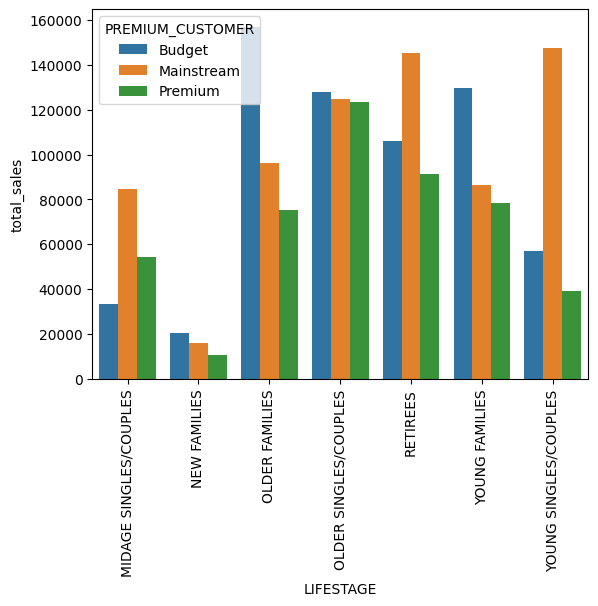

In [ ]:
ax = sns.barplot(data = cross_table,
            x = "LIFESTAGE",
            y = "total_sales",
            hue = "PREMIUM_CUSTOMER")

ax.tick_params(axis="x", rotation = 90)


Sales are coming mainly from Budget - older families, Mainstream - young
singles/couples, and Mainstream - retirees


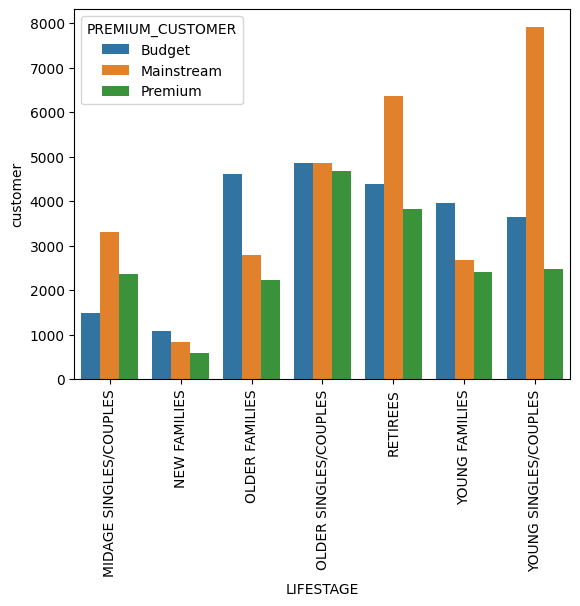

In [ ]:
ax = sns.barplot(data = cross_table,
            x = "LIFESTAGE",
            y = "customer",
            hue = "PREMIUM_CUSTOMER")

ax.tick_params(axis="x", rotation = 90)

There are more Mainstream - young singles/couples and Mainstream - retirees who buy
chips. This contributes to there being more sales to these customer segments but
this is not a major driver for the Budget - Older families segment.

In [ ]:
cross_table = df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"]).agg(
    customers = ("LYLTY_CARD_NBR", "nunique"),
    total_chips = ("PROD_QTY", "sum")
)

cross_table["chips_per_customer"] = (
    cross_table["total_chips"] /
    cross_table["customers"]
    ).round()

cross_table


customers  total_chips  \
LIFESTAGE              PREMIUM_CUSTOMER                           
MIDAGE SINGLES/COUPLES Budget                 1474         8883   
                       Mainstream             3298        21213   
                       Premium                2369        14400   
NEW FAMILIES           Budget                 1087         5241   
                       Mainstream              830         4060   
                       Premium                 575         2769   
OLDER FAMILIES         Budget                 4611        41853   
                       Mainstream             2788        25804   
                       Premium                2231        20239   
OLDER SINGLES/COUPLES  Budget                 4849        32883   
                       Mainstream             4858        32607   
                       Premium                4682        31693   
RETIREES               Budget                 4385        26932   
                       Mainstream             6358        37677   
                       Premium                3812        23266   
YOUNG FAMILIES         Budget                 3953        34482   
                       Mainstream             2685        23194   
                       Premium                2398        20901   
YOUNG SINGLES/COUPLES  Budget                 3647        15500   
                       Mainstream             7917        36225   
                       Premium                2480        10575   

                                         chips_per_customer  
LIFESTAGE              PREMIUM_CUSTOMER                      
MIDAGE SINGLES/COUPLES Budget                           6.0  
                       Mainstream                       6.0  
                       Premium                          6.0  
NEW FAMILIES           Budget                           5.0  
                       Mainstream                       5.0  
                       Premium                          5.0  
OLDER FAMILIES         Budget                           9.0  
                       Mainstream                       9.0  
                       Premium                          9.0  
OLDER SINGLES/COUPLES  Budget                           7.0  
                       Mainstream                       7.0  
                       Premium                          7.0  
RETIREES               Budget                           6.0  
                       Mainstream                       6.0  
                       Premium                          6.0  
YOUNG FAMILIES         Budget                           9.0  
                       Mainstream                       9.0  
                       Premium                          9.0  
YOUNG SINGLES/COUPLES  Budget                           4.0  
                       Mainstream                       5.0  
                       Premium                          4.0

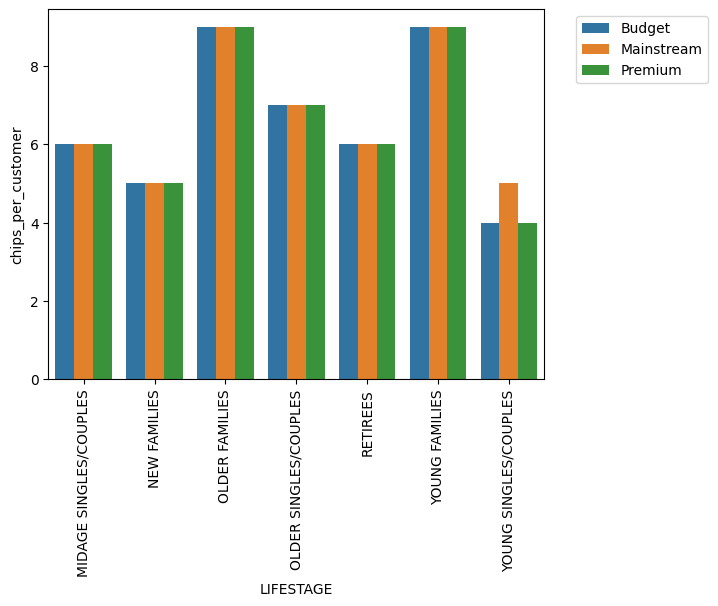

In [ ]:
ax = sns.barplot(data = cross_table,
            x = "LIFESTAGE",
            y = "chips_per_customer",
            hue = "PREMIUM_CUSTOMER")

ax.tick_params(axis="x", rotation = 90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Older families and young families in general buy more chips per customer

In [ ]:
cross_table = df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"]).agg(
    customers = ("LYLTY_CARD_NBR", "nunique"), 
    total_sales = ("TOT_SALES", "sum"),
    total_chips = ("PROD_QTY", "sum")
)

cross_table["avg_price_por_chips_unit"] = (
    cross_table["total_sales"] /
    cross_table["total_chips"]
    ).round(2)

cross_table

customers  total_sales  total_chips  \
LIFESTAGE              PREMIUM_CUSTOMER                                        
MIDAGE SINGLES/COUPLES Budget                 1474     33345.70         8883   
                       Mainstream             3298     84734.25        21213   
                       Premium                2369     54443.85        14400   
NEW FAMILIES           Budget                 1087     20607.45         5241   
                       Mainstream              830     15979.70         4060   
                       Premium                 575     10760.80         2769   
OLDER FAMILIES         Budget                 4611    156863.75        41853   
                       Mainstream             2788     96413.55        25804   
                       Premium                2231     75242.60        20239   
OLDER SINGLES/COUPLES  Budget                 4849    127833.60        32883   
                       Mainstream             4858    124648.50        32607   
                       Premium                4682    123531.55        31693   
RETIREES               Budget                 4385    105916.30        26932   
                       Mainstream             6358    145168.95        37677   
                       Premium                3812     91296.65        23266   
YOUNG FAMILIES         Budget                 3953    129717.95        34482   
                       Mainstream             2685     86338.25        23194   
                       Premium                2398     78571.70        20901   
YOUNG SINGLES/COUPLES  Budget                 3647     57122.10        15500   
                       Mainstream             7917    147582.20        36225   
                       Premium                2480     39052.30        10575   

                                         avg_price_por_chips_unit  
LIFESTAGE              PREMIUM_CUSTOMER                            
MIDAGE SINGLES/COUPLES Budget                                3.75  
                       Mainstream                            3.99  
                       Premium                               3.78  
NEW FAMILIES           Budget                                3.93  
                       Mainstream                            3.94  
                       Premium                               3.89  
OLDER FAMILIES         Budget                                3.75  
                       Mainstream                            3.74  
                       Premium                               3.72  
OLDER SINGLES/COUPLES  Budget                                3.89  
                       Mainstream                            3.82  
                       Premium                               3.90  
RETIREES               Budget                                3.93  
                       Mainstream                            3.85  
                       Premium                               3.92  
YOUNG FAMILIES         Budget                                3.76  
                       Mainstream                            3.72  
                       Premium                               3.76  
YOUNG SINGLES/COUPLES  Budget                                3.69  
                       Mainstream                            4.07  
                       Premium                               3.69

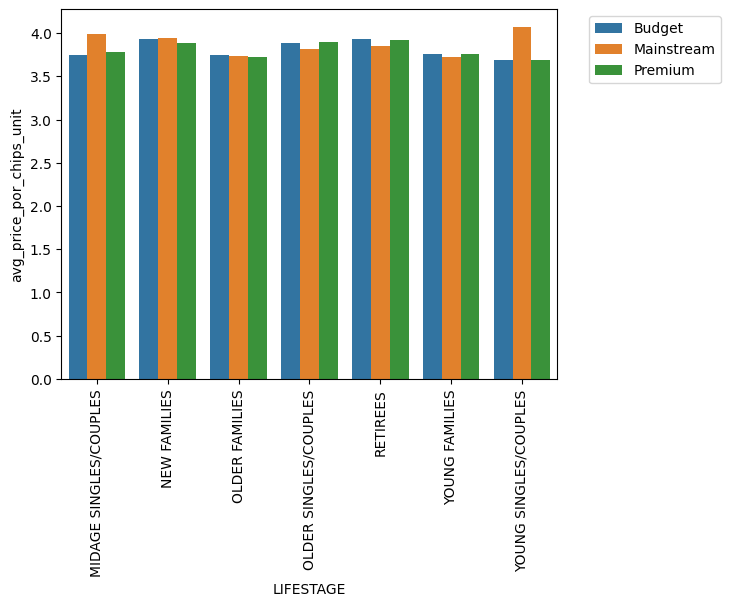

In [ ]:
ax = sns.barplot(data = cross_table,
            x = "LIFESTAGE",
            y = "avg_price_por_chips_unit",
            hue = "PREMIUM_CUSTOMER")

ax.tick_params(axis="x", rotation = 90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Mainstream midage and young singles and couples are more willing to pay more per
packet of chips compared to their budget and premium counterparts. This may be due
to premium shoppers being more likely to buy healthy snacks and when they buy
chips, this is mainly for entertainment purposes rather than their own consumption.
This is also supported by there being fewer premium midage and young singles and
couples buying chips compared to their mainstream counterparts.

# T-test 

In [ ]:
df["price_per_unit"] = df["TOT_SALES"] / df["PROD_QTY"]

target = df[
    df["LIFESTAGE"].isin([
        "MIDAGE SINGLES/COUPLES",
        "YOUNG SINGLES/COUPLES"
    ])
]

mainstream = target[target["PREMIUM_CUSTOMER"] == "Mainstream"]["price_per_unit"]
premium = target[target["PREMIUM_CUSTOMER"] == "Premium"]["price_per_unit"]
budget = target[target["PREMIUM_CUSTOMER"] == "Budget"]["price_per_unit"]

pg.ttest(mainstream, premium)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,28.338015,23871.838249,two-sided,8.840628e-174,"[0.29, 0.34]",0.302753,1.0,6.487e+170


The difference in average price per unit between mainstream and premium customers is statistically significant (p < 0.05), suggesting that the observed difference is unlikely due to random variation.

The t-test results in a p-value of 8.840628e-174, i.e. the unit price for mainstream,
young and mid-age singles and couples ARE significantly higher than
that of budget or premium, young and midage singles and couples.

The t-test shows that the difference in average price per unit between mainstream and premium customers is statistically significant (p < 0.001).
However, the effect size is small (Cohen’s d ≈ 0.3), suggesting that while the difference is consistent, it may not be practically substantial.

# Affinity analysis

In [ ]:
retantion_target = df[(df["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
                      (df["PREMIUM_CUSTOMER"] == "Mainstream")
]

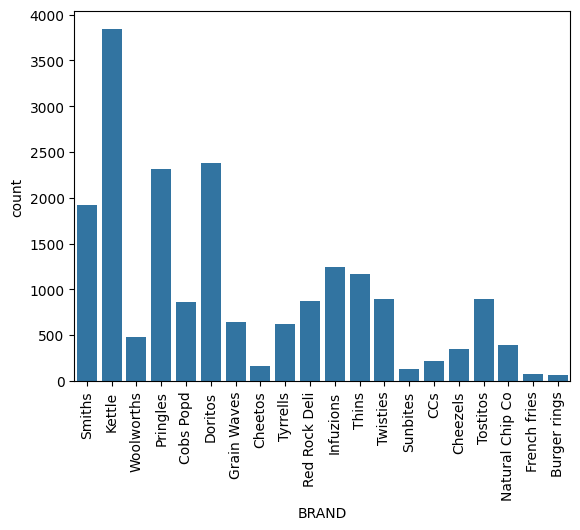

In [ ]:
ax = sns.countplot(data = retantion_target,
            x = "BRAND")

ax.tick_params(axis="x", rotation = 90)

In [ ]:
retantion_target.groupby("TXN_ID")["BRAND"].nunique().describe()

count    19482.000000
mean         1.003028
std          0.055876
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: BRAND, dtype: float64

Mean ≈ 1 per transaction.  Customers typically purchase only one brand per transaction, limiting the applicability of basket analysis.

In [ ]:
retantion_target.groupby("LYLTY_CARD_NBR")["BRAND"].nunique().describe()
top_brands = target["BRAND"].value_counts().head(5).index
target = target[target["BRAND"].isin(top_brands)]

basket = (
    target
    .groupby(["LYLTY_CARD_NBR", "BRAND"])["PROD_QTY"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = (basket > 0).astype(int)


In [ ]:
freq_items = apriori(basket, min_support=0.01, use_colnames=True)

rules = association_rules(freq_items, metric="lift", min_threshold=1)

rules.sort_values("lift", ascending=False).round(2).head(5)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10,"(Red Rock Deli, Kettle)",(Smiths),0.06,0.32,0.03,0.49,1.53,1.0,0.01,1.34,0.37,0.08,0.25,0.29
13,(Smiths),"(Red Rock Deli, Kettle)",0.32,0.06,0.03,0.09,1.53,1.0,0.01,1.03,0.51,0.08,0.03,0.29
17,(Smiths),"(Red Rock Deli, Pringles)",0.32,0.04,0.02,0.06,1.52,1.0,0.01,1.02,0.50,0.06,0.02,0.27
14,"(Red Rock Deli, Pringles)",(Smiths),0.04,0.32,0.02,0.49,1.52,1.0,0.01,1.33,0.36,0.06,0.25,0.27
9,(Smiths),"(Red Rock Deli, Doritos)",0.32,0.04,0.02,0.06,1.51,1.0,0.01,1.02,0.50,0.05,0.02,0.27


# Brand - lift Analysis

In [ ]:
brand_share = (
    retantion_target["BRAND"]
    .value_counts(normalize=True)
    .reset_index()
)
overall = df["BRAND"].value_counts(normalize=True)

segment = retantion_target["BRAND"].value_counts(normalize=True)

comparison = pd.concat([segment, overall], axis=1)
comparison.columns = ["segment", "overall"]

comparison["lift"] = comparison["segment"] / comparison["overall"]
comparison.sort_values("lift", ascending=False)


,segment,overall,lift
BRAND,,,
Tyrrells,0.031672,0.026109,1.213093
Twisties,0.046050,0.038316,1.201853
Doritos,0.121725,0.102229,1.190707
Tostitos,0.045538,0.038385,1.186366
Kettle,0.196684,0.167335,1.175395
Pringles,0.118451,0.101735,1.164306
Cobs Popd,0.044208,0.039284,1.125330
Infuzions,0.063958,0.057555,1.111259
Grain Waves,0.033054,0.031369,1.053697


We can see that :
Mainstream young singles/couples show a clear preference for brands such as Kettle, Doritos and Pringles, which are over-indexed compared to the overall population. In contrast, they are underrepresented in more traditional or budget-oriented brands such as Smiths and Woolworths. This suggests that this segment is more inclined towards differentiated or premium-style snack options.

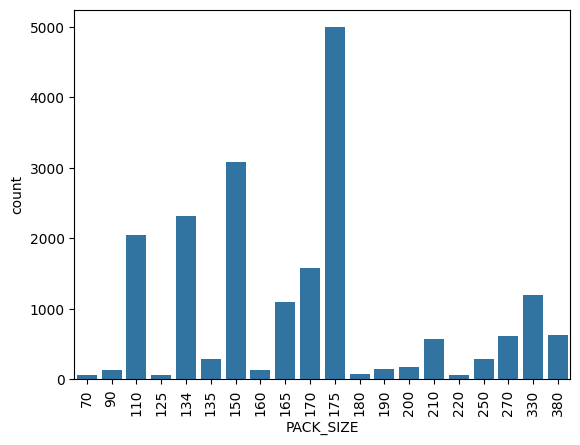

In [ ]:

ax = sns.countplot(data = retantion_target,
            x = "PACK_SIZE")

ax.tick_params(axis="x", rotation = 90)

In [ ]:
retantion_target.groupby("TXN_ID")["PACK_SIZE"].nunique().describe()


count    19482.000000
mean         1.002720
std          0.053065
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: PACK_SIZE, dtype: float64

In [ ]:
retantion_target.groupby("LYLTY_CARD_NBR")["PACK_SIZE"].nunique().describe()


count    7917.000000
mean        2.092586
std         1.266884
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: PACK_SIZE, dtype: float64

In [ ]:
top_brands = target["PACK_SIZE"].value_counts().head(5).index
target = target[target["PACK_SIZE"].isin(top_brands)]

basket = (
    target
    .groupby(["LYLTY_CARD_NBR", "PACK_SIZE"])["PROD_QTY"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = (basket > 0).astype(int)


In [ ]:
freq_items = apriori(basket, min_support=0.01, use_colnames=True)

rules = association_rules(freq_items, metric="lift", min_threshold=1)

rules.sort_values("lift", ascending=False).round(2).head(5)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,"(170, 175)","(150, 134)",0.07,0.11,0.01,0.15,1.28,1.0,0.0,1.04,0.24,0.06,0.04,0.12
7,"(150, 134)","(170, 175)",0.11,0.07,0.01,0.09,1.28,1.0,0.0,1.02,0.25,0.06,0.02,0.12
9,"(150, 175)","(170, 134)",0.12,0.07,0.01,0.08,1.25,1.0,0.0,1.02,0.23,0.06,0.02,0.12
4,"(170, 134)","(150, 175)",0.07,0.12,0.01,0.15,1.25,1.0,0.0,1.04,0.21,0.06,0.03,0.12
5,"(170, 150)","(134, 175)",0.09,0.09,0.01,0.11,1.22,1.0,0.0,1.02,0.20,0.06,0.02,0.11


In [ ]:
size_share = (
    retantion_target["PACK_SIZE"]
    .value_counts(normalize=True)
    .reset_index()
)
overall = df["PACK_SIZE"].value_counts(normalize=True)

segment = retantion_target["PACK_SIZE"].value_counts(normalize=True)

comparison = pd.concat([segment, overall], axis=1)
comparison.columns = ["segment", "overall"]

comparison["lift"] = comparison["segment"] / comparison["overall"]
comparison.sort_values("lift", ascending=False)


,segment,overall,lift
PACK_SIZE,,,
270,0.031723,0.025472,1.245405
380,0.032030,0.026003,1.231783
330,0.061144,0.050823,1.203081
134,0.118451,0.101735,1.164306
210,0.029472,0.025420,1.159420
110,0.104943,0.090732,1.156629
135,0.014838,0.013200,1.124099
250,0.014327,0.012844,1.115476
170,0.080587,0.080988,0.995048


We can see that : 
The segment shows a clear preference for medium (110–134g) and larger pack sizes (270g+), which are over-indexed compared to the overall population.
In contrast, smaller pack sizes are significantly underrepresented, suggesting that this segment is less likely to purchase single-serve or snack-sized options.